# 01 Data Understanding

This notebook documents the **Data Understanding** phase for the AML graph-enhanced data mining project.

Final project scope:
- Dataset: IBM AMLworld `HI-Small_Trans.csv`.
- Main experiment size: 2,000,000 transactions.
- Target: transaction-level binary classification (`is_laundering`).
- Graph interpretation: account = node, transaction = directed edge.
- Key issue: extreme class imbalance, so accuracy is not the main metric.

Outputs used in the report:
- label-distribution chart,
- timestamp/row timeline audit,
- sample graph statistics,
- class imbalance summary for BAB IV.

In [1]:
from pathlib import Path
import sys

# Works when launched from repository root or from notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_transactions
from src.features.graph_features import build_sample_graph, graph_summary

PROJECT_ROOT: /home/acer/dev/aml-graph-dm


## 1. Configuration

Use `NROWS = 2_000_000` to match the final experiment setup. Set `NROWS = None` only if you intentionally want to inspect the full HI-Small file.

In [2]:
DATASET_NAME = "HI-Small"
RAW_PATH = RAW_DIR / f"{DATASET_NAME}_Trans.csv"
NROWS = 2_000_000

print("RAW_PATH:", RAW_PATH)
print("NROWS:", NROWS)

if RAW_PATH.exists():
    df = load_transactions(RAW_PATH, nrows=NROWS)
    display(df.head())
    print("Loaded shape:", df.shape)
else:
    df = None
    print("Raw dataset not found. Put HI-Small_Trans.csv inside data/raw/ to run EDA cells.")

RAW_PATH: /home/acer/dev/aml-graph-dm/data/raw/HI-Small_Trans.csv
NROWS: 2000000


,timestamp,from_bank,sender_account,to_bank,receiver_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,sender_id,receiver_id
0,2022-09-01,220,813720AB1,220,813720AB1,5.234544,Bitcoin,5.234544,Bitcoin,Bitcoin,0,220_813720AB1,220_813720AB1
1,2022-09-01,1412,80E6B8060,1412,80E6B8060,21.100000,US Dollar,21.100000,US Dollar,Reinvestment,0,1412_80E6B8060,1412_80E6B8060
2,2022-09-01,10,803E2BBE0,27564,80E6C2430,2809.450000,US Dollar,2809.450000,US Dollar,Credit Card,0,10_803E2BBE0,27564_80E6C2430
3,2022-09-01,1047,80E6C2FA0,1047,80E6C2FA0,6461.310000,US Dollar,6461.310000,US Dollar,Reinvestment,0,1047_80E6C2FA0,1047_80E6C2FA0
4,2022-09-01,18049,811F7E630,18049,811F7E630,13.070000,Euro,13.070000,Euro,Reinvestment,0,18049_811F7E630,18049_811F7E630


Loaded shape: (2000000, 13)


## 2. Schema and target distribution

This section verifies the available transaction columns and shows the class imbalance.

In [3]:
if df is not None:
    print("Schema:")
    display(df.dtypes)

    label_counts = df["is_laundering"].value_counts(dropna=False).sort_index()
    label_rates = df["is_laundering"].value_counts(normalize=True, dropna=False).sort_index()

    summary = pd.DataFrame({"count": label_counts, "rate": label_rates})
    summary.index = summary.index.map({0: "normal", 1: "laundering"})
    display(summary)

    summary.to_csv(TABLES_DIR / "label_distribution_sample_summary.csv")
    print("Saved:", TABLES_DIR / "label_distribution_sample_summary.csv")
else:
    # Actual known full HI-Small audit result from the project run.
    summary = pd.DataFrame(
        {
            "count": [5_073_168, 5_177],
            "rate": [5_073_168 / 5_078_345, 5_177 / 5_078_345],
        },
        index=["normal", "laundering"],
    )
    display(summary)

Schema:


timestamp             datetime64[us]
from_bank                      int64
sender_account                   str
to_bank                        int64
receiver_account                 str
amount_received              float64
receiving_currency               str
amount_paid                  float64
payment_currency                 str
payment_format                   str
is_laundering                  int64
sender_id                        str
receiver_id                      str
dtype: object

,count,rate
is_laundering,,
normal,1998502,0.999251
laundering,1498,0.000749


Saved: /home/acer/dev/aml-graph-dm/reports/tables/label_distribution_sample_summary.csv


## 3. Label distribution figure

The laundering class is extremely rare. This is why the project uses PR-AUC, F1, precision, recall, and Top-K metrics instead of accuracy.

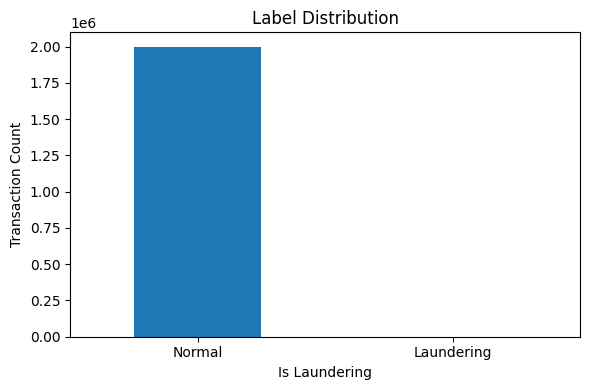

Saved: /home/acer/dev/aml-graph-dm/reports/figures/label_distribution.png


In [4]:
if df is not None:
    label_plot = df["is_laundering"].value_counts().sort_index()
else:
    label_plot = pd.Series({0: 5_073_168, 1: 5_177})

ax = label_plot.plot(kind="bar", figsize=(6, 4))
ax.set_title("Label Distribution")
ax.set_xlabel("Is Laundering")
ax.set_ylabel("Transaction Count")
ax.set_xticklabels(["Normal", "Laundering"], rotation=0)
plt.tight_layout()

out_path = FIGURES_DIR / "label_distribution.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 4. Transaction field overview

Inspect payment formats, banks, and currencies. These columns become raw transaction features or categorical inputs.

In [5]:
if df is not None:
    for col in ["payment_format", "payment_currency", "receiving_currency", "from_bank", "to_bank"]:
        if col in df.columns:
            print(f"\nTop values for {col}:")
            display(df[col].value_counts(dropna=False).head(10))
else:
    print("Skipped because raw dataset is not loaded.")


Top values for payment_format:


payment_format
Cheque          611741
Reinvestment    481056
Credit Card     422147
ACH             206713
Cash            164048
Wire             57933
Bitcoin          56362
Name: count, dtype: int64


Top values for payment_currency:


payment_currency
US Dollar      747766
Euro           461252
Swiss Franc     92639
Yuan            84116
Shekel          75771
Rupee           74865
UK Pound        70300
Yen             61579
Ruble           61210
Bitcoin         56349
Name: count, dtype: int64


Top values for receiving_currency:


receiving_currency
US Dollar      742724
Euro           462558
Swiss Franc     93636
Yuan            81768
Shekel          76679
Rupee           75438
UK Pound        70444
Ruble           61895
Yen             61893
Bitcoin         57034
Name: count, dtype: int64


Top values for from_bank:


from_bank
70     143255
10      28468
12      27664
1       21562
15      19170
220     18448
20      14389
3       13756
7       11299
211     10959
Name: count, dtype: int64


Top values for to_bank:


to_bank
10     16312
12     16218
15     14880
220    11904
1      11631
3       9837
7       8827
20      8519
28      8183
211     7934
Name: count, dtype: int64

## 5. Timestamp coverage and daily label trend

AML scoring is temporal, so the project uses chronological splitting and past-only graph features.

In [6]:
if df is not None and "timestamp" in df.columns:
    print("Minimum timestamp:", df["timestamp"].min())
    print("Maximum timestamp:", df["timestamp"].max())
    print("Number of unique timestamps:", df["timestamp"].nunique())

    daily = (
        df.assign(date=df["timestamp"].dt.date)
        .groupby("date")
        .agg(
            rows=("is_laundering", "size"),
            laundering_count=("is_laundering", "sum"),
            laundering_rate=("is_laundering", "mean"),
        )
        .reset_index()
    )
    display(daily.head())
    display(daily.tail())

    daily.to_csv(TABLES_DIR / "daily_label_distribution_sample.csv", index=False)
    print("Saved:", TABLES_DIR / "daily_label_distribution_sample.csv")
else:
    print("Skipped because raw dataset is not loaded or timestamp column is missing.")

Minimum timestamp: 2022-09-01 00:00:00
Maximum timestamp: 2022-09-10 13:24:00
Number of unique timestamps: 4243


,date,rows,laundering_count,laundering_rate
0,2022-09-01,1114921,322,0.000289
1,2022-09-02,754449,408,0.000541
2,2022-09-03,129805,309,0.002380
3,2022-09-04,331,187,0.564955
4,2022-09-05,200,116,0.580000


,date,rows,laundering_count,laundering_rate
5,2022-09-06,181,95,0.524862
6,2022-09-07,42,22,0.523810
7,2022-09-08,39,22,0.564103
8,2022-09-09,24,13,0.541667
9,2022-09-10,8,4,0.500000


Saved: /home/acer/dev/aml-graph-dm/reports/tables/daily_label_distribution_sample.csv


## 6. Label timeline audit by row chunks

This table is useful for explaining why chronological split matters: laundering prevalence changes over time/row order.

In [7]:
timeline_path = TABLES_DIR / "hi_small_label_timeline.csv"

if timeline_path.exists():
    timeline = pd.read_csv(timeline_path)
else:
    timeline = pd.DataFrame([
        {"chunk_id": 1, "rows": 250000, "laundering_count": 26, "laundering_rate": 0.000104},
        {"chunk_id": 8, "rows": 250000, "laundering_count": 414, "laundering_rate": 0.001656},
        {"chunk_id": 21, "rows": 78345, "laundering_count": 229, "laundering_rate": 0.002923},
    ])
    print("Timeline file not found. Showing a small fallback preview. To create the full file, run:")
    print("PYTHONPATH=. python scripts/audit_label_timeline.py --dataset HI-Small --chunksize 250000")

display(timeline)

,chunk_id,start_row,end_row,rows,normal_count,laundering_count,laundering_rate,min_timestamp,max_timestamp
0,1,0,249999,250000,249974,26,0.000104,2022-09-01 00:00:00,2022-09-04 15:48:00
1,2,250000,499999,250000,249833,167,0.000668,2022-09-01 00:00:00,2022-09-06 19:16:00
2,3,500000,749999,250000,249798,202,0.000808,2022-09-01 05:30:00,2022-09-08 01:16:00
3,4,750000,999999,250000,249820,180,0.000720,2022-09-01 13:00:00,2022-09-09 08:29:00
4,5,1000000,1249999,250000,249819,181,0.000724,2022-09-01 20:30:00,2022-09-09 17:14:00
5,6,1250000,1499999,250000,249871,129,0.000516,2022-09-02 03:30:00,2022-09-06 11:33:00
6,7,1500000,1749999,250000,249801,199,0.000796,2022-09-02 11:30:00,2022-09-06 16:16:00
7,8,1750000,1999999,250000,249586,414,0.001656,2022-09-02 20:00:00,2022-09-10 13:24:00
8,9,2000000,2249999,250000,249501,499,0.001996,2022-09-03 14:00:00,2022-09-11 03:21:00
9,10,2250000,2499999,250000,249669,331,0.001324,2022-09-04 19:30:00,2022-09-11 19:16:00


## 7. Sample graph statistics

A small graph sample is enough for EDA. Full graph features are created in `02_feature_engineering.ipynb` and the `src/features/` modules.

In [8]:
if df is not None:
    G = build_sample_graph(df, max_edges=50_000)
    graph_stats = graph_summary(G)
    graph_summary_df = pd.DataFrame([graph_stats])
    display(graph_summary_df)
    graph_summary_df.to_csv(TABLES_DIR / "sample_graph_summary.csv", index=False)
    print("Saved:", TABLES_DIR / "sample_graph_summary.csv")
else:
    print("Skipped because raw dataset is not loaded.")

,nodes,edges,density,weak_components,largest_weak_component,avg_in_degree,avg_out_degree
0,57051,48128,0.000015,44578,354,0.843596,0.843596


Saved: /home/acer/dev/aml-graph-dm/reports/tables/sample_graph_summary.csv


## 8. Chronological split and imbalance EDA

This section shows the class imbalance in the exact chronological split used by the modeling pipeline. It is useful for BAB III/BAB IV because the minority class is not evenly distributed through time.

,split,rows,laundering_count,laundering_rate,min_timestamp,max_timestamp
0,train,1200000,361,0.000301,2022-09-01 00:00:00,2022-09-02 02:16:00
1,validation,400000,227,0.000567,2022-09-02 02:16:00,2022-09-02 15:14:00
2,test,400000,910,0.002275,2022-09-02 15:14:00,2022-09-10 13:24:00


Saved: /home/acer/dev/aml-graph-dm/reports/tables/chronological_split_label_summary.csv


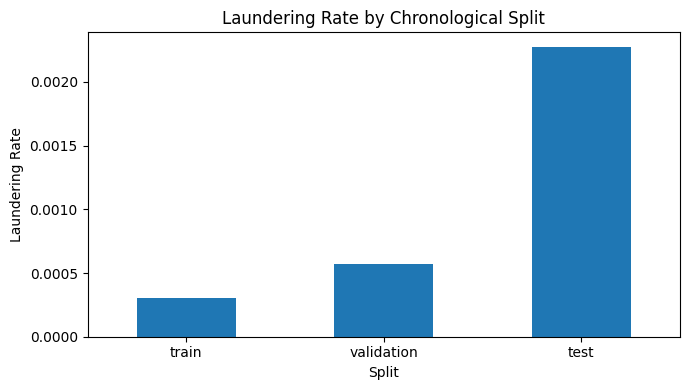

Saved: /home/acer/dev/aml-graph-dm/reports/figures/chronological_split_laundering_rate.png


In [9]:
if df is not None:
    ordered = df.sort_values("timestamp").reset_index(drop=True)
    n = len(ordered)
    train_end = int(n * 0.60)
    val_end = int(n * 0.80)

    split_df = pd.concat([
        ordered.iloc[:train_end].assign(split="train"),
        ordered.iloc[train_end:val_end].assign(split="validation"),
        ordered.iloc[val_end:].assign(split="test"),
    ])

    split_summary = (
        split_df.groupby("split")
        .agg(
            rows=("is_laundering", "size"),
            laundering_count=("is_laundering", "sum"),
            laundering_rate=("is_laundering", "mean"),
            min_timestamp=("timestamp", "min"),
            max_timestamp=("timestamp", "max"),
        )
        .reindex(["train", "validation", "test"])
        .reset_index()
    )

    display(split_summary)
    split_summary.to_csv(TABLES_DIR / "chronological_split_label_summary.csv", index=False)
    print("Saved:", TABLES_DIR / "chronological_split_label_summary.csv")

    ax = split_summary.plot(kind="bar", x="split", y="laundering_rate", legend=False, figsize=(7, 4))
    ax.set_title("Laundering Rate by Chronological Split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Laundering Rate")
    plt.xticks(rotation=0)
    plt.tight_layout()

    out_path = FIGURES_DIR / "chronological_split_laundering_rate.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)
else:
    print("Skipped because raw dataset is not loaded.")

## 9. Graph structural EDA: degree, PageRank, and components

This is an **exploratory static sample analysis**, not the final leakage-safe model feature calculation. The goal is to show why graph structure is relevant: some accounts become central receivers/senders, and laundering labels may concentrate around certain graph positions.

For runtime safety, the graph is built from a small sample (`EDA_GRAPH_ROWS`).

Sample graph nodes: 105621
Sample graph edges: 92967


,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,component_size
count,105621.000000,105621.000000,1.056210e+05,1.056210e+05,105621.000000,105621.000000
mean,0.880194,0.880194,7.379680e+06,7.379680e+06,0.000009,7.430426
std,0.439849,2.264184,3.286487e+08,3.358729e+08,0.000004,57.112898
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000003,1.000000
50%,1.000000,1.000000,8.865100e+02,6.485700e+02,0.000011,1.000000
90%,1.000000,1.000000,4.320049e+05,3.997637e+05,0.000011,2.000000
95%,1.000000,1.000000,1.970451e+06,1.851299e+06,0.000011,3.000000
99%,2.000000,2.000000,3.211653e+07,3.051847e+07,0.000019,101.000000
max,18.000000,600.000000,4.636551e+10,4.943792e+10,0.000141,659.000000


,account_id,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,component_size
17217,254958_8146532E1,18,1,1.212052e+01,8.717746e+00,0.000141,18
14511,15980_812F0D2B0,13,0,3.485781e+04,0.000000e+00,0.000093,14
5942,41148_80F4E9610,7,0,1.287359e+04,0.000000e+00,0.000059,9
12853,240915_812E358A0,7,0,1.198783e+05,0.000000e+00,0.000052,10
5899,138335_80EB78550,6,0,9.510563e+04,0.000000e+00,0.000051,7
2515,16678_8065DE360,6,1,2.126990e+06,9.835537e+05,0.000051,6
199,10605_80B1968F0,5,0,1.633286e+06,0.000000e+00,0.000042,6
7122,23833_8018859B0,5,0,8.307500e+02,0.000000e+00,0.000035,9
11446,148785_812A932E0,4,1,2.031776e+04,2.846000e+01,0.000035,4
32515,53744_813EB2201,4,1,2.660770e-01,6.110000e-04,0.000035,4


Saved: /home/acer/dev/aml-graph-dm/reports/tables/sample_graph_centrality_summary.csv


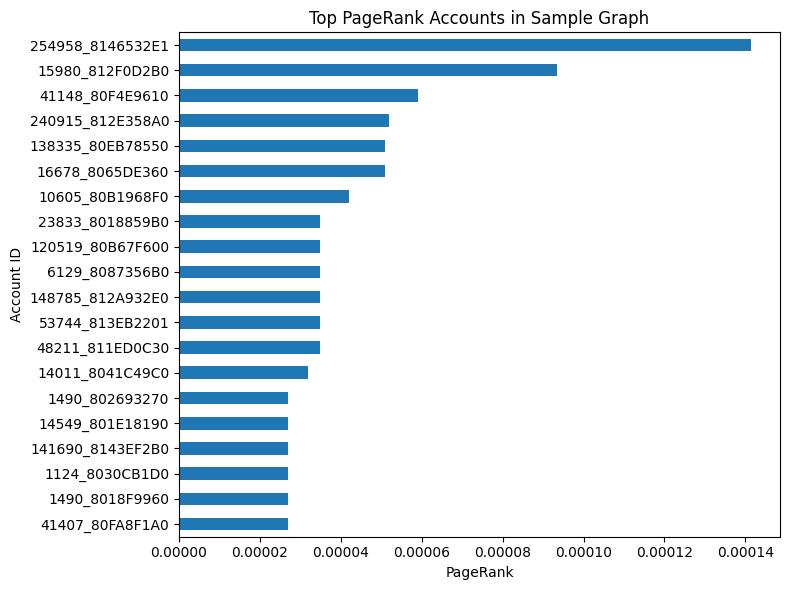

Saved: /home/acer/dev/aml-graph-dm/reports/figures/sample_top_pagerank_accounts.png


In [10]:
import networkx as nx

EDA_GRAPH_ROWS = 100_000

if df is not None:
    graph_sample = df.head(min(EDA_GRAPH_ROWS, len(df))).copy()

    edges = (
        graph_sample.groupby(["sender_id", "receiver_id"])
        .agg(
            tx_count=("is_laundering", "size"),
            laundering_count=("is_laundering", "sum"),
            total_amount=("amount_paid", "sum"),
        )
        .reset_index()
    )

    G = nx.DiGraph()
    for row in edges.itertuples(index=False):
        G.add_edge(
            str(row.sender_id),
            str(row.receiver_id),
            weight=float(row.total_amount),
            tx_count=int(row.tx_count),
            laundering_count=int(row.laundering_count),
        )

    print("Sample graph nodes:", G.number_of_nodes())
    print("Sample graph edges:", G.number_of_edges())

    if G.number_of_edges() > 0:
        pagerank = nx.pagerank(G, alpha=0.85, max_iter=50, tol=1e-4, weight="weight")
        weak_components = list(nx.weakly_connected_components(G))
        component_size = {}
        for comp in weak_components:
            size = len(comp)
            for node in comp:
                component_size[node] = size

        centrality_df = pd.DataFrame({
            "account_id": list(G.nodes()),
            "in_degree": [G.in_degree(n) for n in G.nodes()],
            "out_degree": [G.out_degree(n) for n in G.nodes()],
            "weighted_in_degree": [G.in_degree(n, weight="weight") for n in G.nodes()],
            "weighted_out_degree": [G.out_degree(n, weight="weight") for n in G.nodes()],
            "pagerank": [pagerank.get(n, 0.0) for n in G.nodes()],
            "component_size": [component_size.get(n, 0) for n in G.nodes()],
        })

        display(centrality_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
        display(centrality_df.sort_values("pagerank", ascending=False).head(15))

        centrality_df.to_csv(TABLES_DIR / "sample_graph_centrality_summary.csv", index=False)
        print("Saved:", TABLES_DIR / "sample_graph_centrality_summary.csv")

        top_pr = centrality_df.sort_values("pagerank", ascending=True).tail(20)
        ax = top_pr.plot(kind="barh", x="account_id", y="pagerank", legend=False, figsize=(8, 6))
        ax.set_title("Top PageRank Accounts in Sample Graph")
        ax.set_xlabel("PageRank")
        ax.set_ylabel("Account ID")
        plt.tight_layout()
        out_path = FIGURES_DIR / "sample_top_pagerank_accounts.png"
        plt.savefig(out_path, dpi=150)
        plt.show()
        print("Saved:", out_path)
else:
    print("Skipped because raw dataset is not loaded.")

## 10. PageRank/degree profile by laundering label

This cell joins sample-level graph statistics back to transactions and compares the graph position of normal versus laundering transactions.

This is useful for explaining PageRank in BAB IV, even though the final selected model uses split-safe node2vec and temporal graph features rather than static full-graph PageRank.

sender_pagerank_sample                      \
                                mean    median       max   
is_laundering                                              
0                           0.000009  0.000011  0.000141   
1                           0.000007  0.000009  0.000011   

              receiver_pagerank_sample                      \
                                  mean    median       max   
is_laundering                                                
0                             0.000011  0.000011  0.000141   
1                             0.000008  0.000010  0.000015   

              sender_out_degree_sample             receiver_in_degree_sample  \
                                  mean median  max                      mean   
is_laundering                                                                  
0                             7.559765    1.0  600                  1.103888   
1                           235.625000   40.0  600                  1.375000   

               ...     sender_component_size_sample              \
               ... max                         mean median  max   
is_laundering  ...                                                
0              ...  18                    10.238269    1.0  659   
1              ...   2                   259.125000   45.0  659   

              receiver_component_size_sample               amount_paid  \
                                        mean median  max          mean   
is_laundering                                                            
0                                  10.238269    1.0  659  7.794612e+06   
1                                 259.125000   45.0  659  6.297155e+06   

                                        
                  median           max  
is_laundering                           
0               2369.445  3.188119e+10  
1              31639.490  3.708012e+07  

[2 rows x 21 columns]

Saved: /home/acer/dev/aml-graph-dm/reports/tables/graph_profile_by_label_sample.csv


,normal,laundering
sender_pagerank_sample,0.000009,0.000007
receiver_pagerank_sample,0.000011,0.000008
sender_out_degree_sample,7.559765,235.625000
receiver_in_degree_sample,1.103888,1.375000


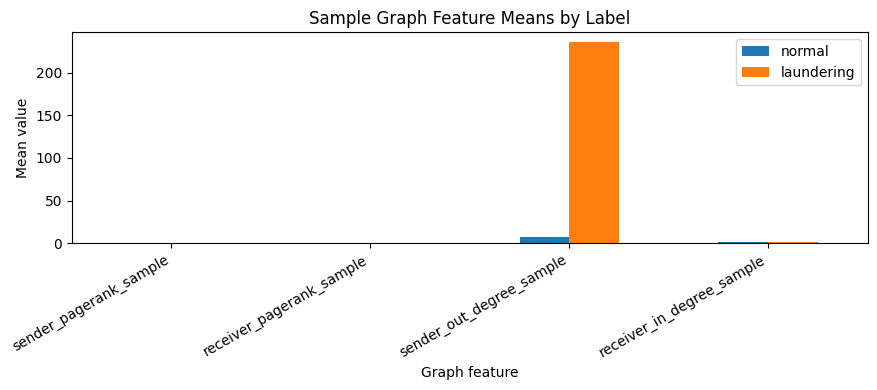

Saved: /home/acer/dev/aml-graph-dm/reports/figures/sample_graph_feature_means_by_label.png


In [11]:
if df is not None and "centrality_df" in globals():
    cent = centrality_df.set_index("account_id")
    graph_sample = graph_sample.copy()

    for prefix, col in [("sender", "sender_id"), ("receiver", "receiver_id")]:
        ids = graph_sample[col].astype(str)
        graph_sample[f"{prefix}_pagerank_sample"] = ids.map(cent["pagerank"]).fillna(0.0)
        graph_sample[f"{prefix}_in_degree_sample"] = ids.map(cent["in_degree"]).fillna(0.0)
        graph_sample[f"{prefix}_out_degree_sample"] = ids.map(cent["out_degree"]).fillna(0.0)
        graph_sample[f"{prefix}_component_size_sample"] = ids.map(cent["component_size"]).fillna(0.0)

    graph_profile_by_label = (
        graph_sample.groupby("is_laundering")[[
            "sender_pagerank_sample",
            "receiver_pagerank_sample",
            "sender_out_degree_sample",
            "receiver_in_degree_sample",
            "sender_component_size_sample",
            "receiver_component_size_sample",
            "amount_paid",
        ]]
        .agg(["mean", "median", "max"])
    )

    display(graph_profile_by_label)
    graph_profile_by_label.to_csv(TABLES_DIR / "graph_profile_by_label_sample.csv")
    print("Saved:", TABLES_DIR / "graph_profile_by_label_sample.csv")

    plot_cols = ["sender_pagerank_sample", "receiver_pagerank_sample", "sender_out_degree_sample", "receiver_in_degree_sample"]
    label_means = graph_sample.groupby("is_laundering")[plot_cols].mean().T
    label_means.columns = ["normal", "laundering"] if len(label_means.columns) == 2 else label_means.columns
    display(label_means)

    ax = label_means.plot(kind="bar", figsize=(9, 4))
    ax.set_title("Sample Graph Feature Means by Label")
    ax.set_xlabel("Graph feature")
    ax.set_ylabel("Mean value")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    out_path = FIGURES_DIR / "sample_graph_feature_means_by_label.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)
else:
    print("Skipped because raw dataset or centrality sample is not available.")

## 11. Reciprocal edge and cycle-proxy EDA

A full cycle enumeration is expensive on millions of edges. For EDA, we use a simple reciprocal-edge proxy: if `A → B` exists and `B → A` also exists in the sample graph. This motivates the `reverse_pair_*`, `reciprocal_pair_score`, and `cycle_proxy_score` features used later.

,has_reverse_edge_sample,rows,laundering_count,laundering_rate,median_amount,mean_amount
0,0,27134,8,0.000295,6062.165,2.215027e+07
1,1,72866,0,0.000000,1432.675,2.448655e+06


Saved: /home/acer/dev/aml-graph-dm/reports/tables/reciprocal_edge_summary_sample.csv


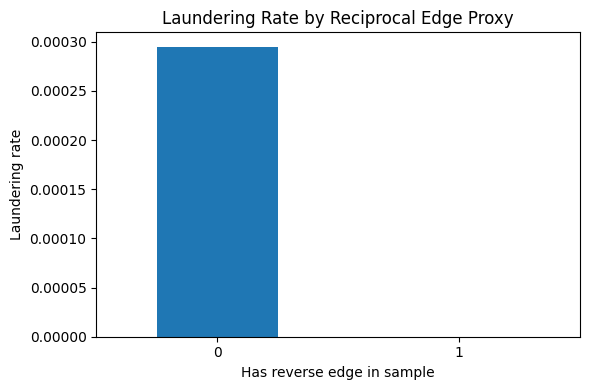

Saved: /home/acer/dev/aml-graph-dm/reports/figures/reciprocal_edge_laundering_rate_sample.png


In [12]:
if df is not None and "graph_sample" in globals():
    pair_set = set(zip(graph_sample["sender_id"].astype(str), graph_sample["receiver_id"].astype(str)))

    graph_sample["has_reverse_edge_sample"] = [
        int((str(receiver), str(sender)) in pair_set)
        for sender, receiver in zip(graph_sample["sender_id"], graph_sample["receiver_id"])
    ]

    reciprocal_summary = (
        graph_sample.groupby("has_reverse_edge_sample")
        .agg(
            rows=("is_laundering", "size"),
            laundering_count=("is_laundering", "sum"),
            laundering_rate=("is_laundering", "mean"),
            median_amount=("amount_paid", "median"),
            mean_amount=("amount_paid", "mean"),
        )
        .reset_index()
    )

    display(reciprocal_summary)
    reciprocal_summary.to_csv(TABLES_DIR / "reciprocal_edge_summary_sample.csv", index=False)
    print("Saved:", TABLES_DIR / "reciprocal_edge_summary_sample.csv")

    ax = reciprocal_summary.plot(kind="bar", x="has_reverse_edge_sample", y="laundering_rate", legend=False, figsize=(6, 4))
    ax.set_title("Laundering Rate by Reciprocal Edge Proxy")
    ax.set_xlabel("Has reverse edge in sample")
    ax.set_ylabel("Laundering rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    out_path = FIGURES_DIR / "reciprocal_edge_laundering_rate_sample.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)
else:
    print("Skipped because graph sample is not available.")

## Data-understanding notes for BAB IV

Write these points in the report:
- The dataset is highly imbalanced; laundering transactions are rare.
- Full HI-Small has 5,078,345 transactions with 5,177 laundering transactions, or about 0.1019% laundering rate.
- Each transaction can be interpreted as a directed graph edge from sender account to receiver account.
- Chronological splitting is more realistic than random splitting because AML scoring should use past behavior to score future transactions.
- Accuracy is not a suitable main metric because the majority class dominates the data.
- Additional EDA includes PageRank/degree sample analysis, split imbalance summaries, and reciprocal-edge/cycle-proxy analysis. These support the graph-based explanation without making static PageRank the final model feature.